In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


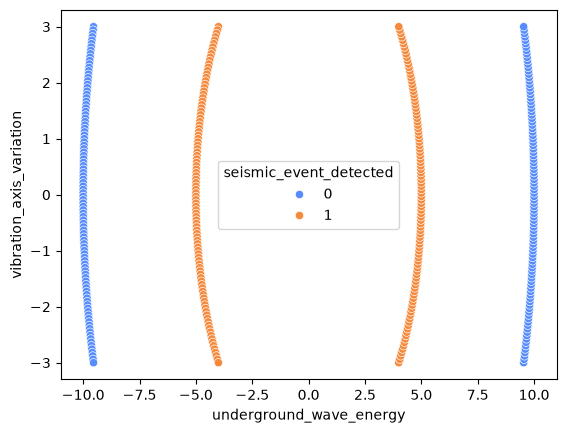

In [5]:
sns.scatterplot(x=df['underground_wave_energy'],y=df['vibration_axis_variation'],hue=df['seismic_event_detected'])
plt.show()

In [6]:
X = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [7]:
X

array([[ 9.53939201, -3.        ],
       [ 9.55824059, -2.93939394],
       [ 9.57666854, -2.87878788],
       [ 9.59467828, -2.81818182],
       [ 9.61227215, -2.75757576],
       [ 9.62945245, -2.6969697 ],
       [ 9.64622137, -2.63636364],
       [ 9.66258107, -2.57575758],
       [ 9.67853361, -2.51515152],
       [ 9.69408101, -2.45454545],
       [ 9.70922521, -2.39393939],
       [ 9.7239681 , -2.33333333],
       [ 9.73831149, -2.27272727],
       [ 9.75225716, -2.21212121],
       [ 9.76580681, -2.15151515],
       [ 9.77896207, -2.09090909],
       [ 9.79172455, -2.03030303],
       [ 9.80409577, -1.96969697],
       [ 9.81607722, -1.90909091],
       [ 9.82767031, -1.84848485],
       [ 9.83887643, -1.78787879],
       [ 9.8496969 , -1.72727273],
       [ 9.86013297, -1.66666667],
       [ 9.87018588, -1.60606061],
       [ 9.87985679, -1.54545455],
       [ 9.88914683, -1.48484848],
       [ 9.89805706, -1.42424242],
       [ 9.90658851, -1.36363636],
       [ 9.91474216,

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)   # shape: (320, 2)
X_test  = torch.tensor(X_test,  dtype=torch.float32)   # shape: (80, 2)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # shape: (320, 1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1) # shape: (80, 1)

In [11]:
y_train.shape

torch.Size([320, 1])

In [12]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [13]:
from torch import nn

In [14]:
class ClassificationNonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function

    def forward(self, x):
      # ReLU function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


In [15]:
model_0 = ClassificationNonLinearModel()

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.01)

In [17]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item() # torch.eq() calculates when two tensors are equal
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [18]:
torch.manual_seed(42)
epochs = 260

for epoch in range(epochs):
    # Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probs -> pred labls

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
    acc = calculate_accuracy(y_test=y_train,
                      y_pred=y_pred)

    # 3. optimizer reset
    optimizer.zero_grad()

    # 4. back prop and optimization
    loss.backward()

    # 5.
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = calculate_accuracy(y_test=y_test,
                               y_pred=test_pred)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.73828, Accuracy: 29.69% | Test loss: 0.70080, Test acc: 55.00%
Epoch: 20 | Loss: 0.49276, Accuracy: 74.06% | Test loss: 0.49849, Test acc: 73.75%
Epoch: 40 | Loss: 0.15885, Accuracy: 100.00% | Test loss: 0.14051, Test acc: 100.00%
Epoch: 60 | Loss: 0.01736, Accuracy: 100.00% | Test loss: 0.01524, Test acc: 100.00%
Epoch: 80 | Loss: 0.00467, Accuracy: 100.00% | Test loss: 0.00423, Test acc: 100.00%
Epoch: 100 | Loss: 0.00258, Accuracy: 100.00% | Test loss: 0.00231, Test acc: 100.00%
Epoch: 120 | Loss: 0.00181, Accuracy: 100.00% | Test loss: 0.00164, Test acc: 100.00%
Epoch: 140 | Loss: 0.00138, Accuracy: 100.00% | Test loss: 0.00126, Test acc: 100.00%
Epoch: 160 | Loss: 0.00110, Accuracy: 100.00% | Test loss: 0.00100, Test acc: 100.00%
Epoch: 180 | Loss: 0.00089, Accuracy: 100.00% | Test loss: 0.00081, Test acc: 100.00%
Epoch: 200 | Loss: 0.00074, Accuracy: 100.00% | Test loss: 0.00068, Test acc: 100.00%
Epoch: 220 | Loss: 0.00063, Accuracy: 100.00% | Test loss: 0.000

In [21]:
import numpy as np
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)

    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

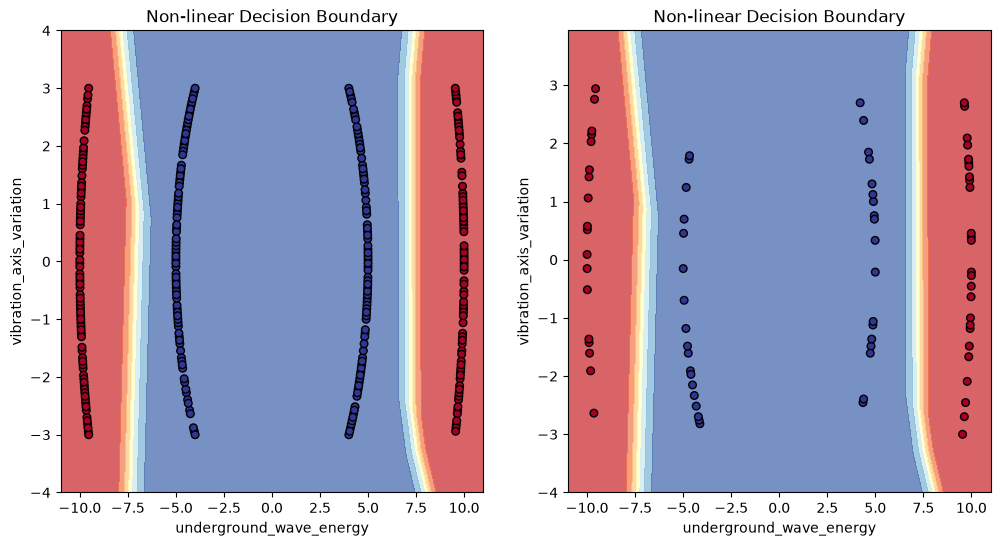

In [22]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model_0, X_test, y_test)

plt.show()